# Week 7 - Exercises

## Exercise 1: NLPP Chapter 1

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from collections import Counter
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

abstracts = pd.read_json("week3_css_abstracts.json")
print(abstracts.shape)
print(abstracts.columns.tolist())
print(abstracts.head(2))

[nltk_data] Downloading package punkt to /Users/p/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/p/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/p/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


(47599, 3)
['id', 'title', 'abstract_inverted_index']
                                 id  \
0  https://openalex.org/W2047940964   
1  https://openalex.org/W3103362336   

                                               title  \
0  Finding community structure in very large netw...   
1          Power-law distributions in empirical data   

                             abstract_inverted_index  
0  {'The': [0, 158], 'discovery': [1], 'and': [2,...  
1  {'Power-law': [0], 'distributions': [1, 64], '...  


In [5]:
def inverted_index_to_text(inv_index):
    """Convert OpenAlex inverted index to plain text."""
    if inv_index is None or not isinstance(inv_index, dict):
        return ""
    word_positions = []
    for word, positions in inv_index.items():
        for pos in positions:
            word_positions.append((pos, word))
    word_positions.sort()
    return " ".join(word for _, word in word_positions)

# apply to all abstracts
abstracts["text"] = abstracts["abstract_inverted_index"].apply(inverted_index_to_text)
print(abstracts["text"].iloc[0][:300])

The discovery and analysis of community structure in networks is a topic of considerable recent interest within the physics community, but most methods proposed so far are unsuitable for very large networks because of their computational cost. Here we present a hierarchical agglomeration algorithm f


In [6]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

stop_words = set(stopwords.words('english'))

def tokenize(text):
    """Tokenize text: lowercase, remove punctuation/numbers/stopwords."""
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if re.match(r'^[a-z]{2,}$', t)]  # only alpha, 2+ chars
    tokens = [t for t in tokens if t not in stop_words]
    return tokens

abstracts["tokens"] = abstracts["text"].apply(tokenize)
print(abstracts["tokens"].iloc[0][:20])

['discovery', 'analysis', 'community', 'structure', 'networks', 'topic', 'considerable', 'recent', 'interest', 'within', 'physics', 'community', 'methods', 'proposed', 'far', 'unsuitable', 'large', 'networks', 'computational', 'cost']


Total tokens: 3371569
  data: 20452
  social: 19619
  model: 16359
  study: 14459
  results: 14220
  information: 13435
  research: 12936
  nan: 12346
  using: 11536
  different: 10644


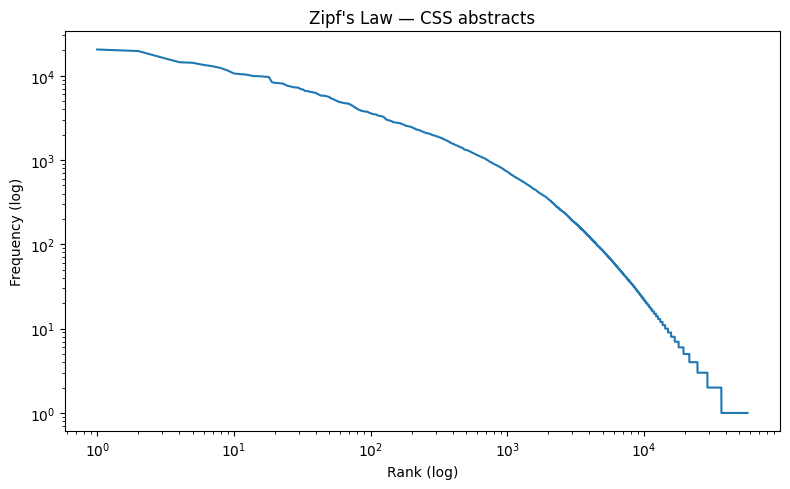

In [7]:
# step 3: combine all tokens
all_tokens = abstracts["tokens"].explode().tolist()
print(f"Total tokens: {len(all_tokens)}")

# step 4: top 10 most frequent
freq = Counter(all_tokens)
for word, count in freq.most_common(10):
    print(f"  {word}: {count}")

# step 5: zipf plot
counts = sorted(freq.values(), reverse=True)
ranks = range(1, len(counts) + 1)

plt.figure(figsize=(8, 5))
plt.loglog(ranks, counts)
plt.xlabel("Rank (log)")
plt.ylabel("Frequency (log)")
plt.title("Zipf's Law — CSS abstracts")
plt.tight_layout()
plt.show()

In [8]:
def tokenize(text):
    """Tokenize text: lowercase, remove punctuation/numbers/stopwords."""
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if re.match(r'^[a-z]{2,}$', t)]
    tokens = [t for t in tokens if t not in stop_words and t != "nan"]
    return tokens

abstracts["tokens"] = abstracts["text"].apply(tokenize)

# Exercise 2, step 1: find bigrams per abstract
all_bigrams = []
for tokens in abstracts["tokens"]:
    bgs = list(nltk.bigrams(tokens))
    all_bigrams.extend(bgs)

print(f"Total bigrams: {len(all_bigrams)}")
bigram_counts = Counter(all_bigrams)
print(f"Unique bigrams: {len(bigram_counts)}")
print("\nTop 10 bigrams:")
for bg, count in bigram_counts.most_common(10):
    print(f"  {bg}: {count}")

Total bigrams: 3323965
Unique bigrams: 1757864

Top 10 bigrams:
  ('social', 'media'): 3792
  ('results', 'show'): 1773
  ('machine', 'learning'): 1458
  ('social', 'networks'): 1298
  ('social', 'network'): 1133
  ('paper', 'propose'): 1111
  ('experimental', 'results'): 1061
  ('results', 'suggest'): 1043
  ('natural', 'language'): 925
  ('future', 'research'): 890


In [11]:
from scipy.stats import chi2

N = len(all_bigrams)  # total number of bigrams

# count individual words in first and second position
first_word_counts = Counter()
second_word_counts = Counter()
for (w1, w2) in all_bigrams:
    first_word_counts[w1] += 1
    second_word_counts[w2] += 1

# compute chi-squared for each unique bigram
chi2_results = []
for (w1, w2), n_ii in bigram_counts.items():
    n_io = first_word_counts[w1] - n_ii
    n_oi = second_word_counts[w2] - n_ii
    n_oo = N - n_ii - n_io - n_oi
    
    R1 = n_ii + n_io
    R2 = n_oi + n_oo
    C1 = n_ii + n_oi
    C2 = n_io + n_oo
    
    # expected values
    E_ii = R1 * C1 / N
    E_io = R1 * C2 / N
    E_oi = R2 * C1 / N
    E_oo = R2 * C2 / N
    
    # chi-squared
    X2 = 0
    for O, E in [(n_ii, E_ii), (n_io, E_io), (n_oi, E_oi), (n_oo, E_oo)]:
        if E > 0:
            X2 += (O - E) ** 2 / E
    
    p_value = chi2.sf(X2, df=1)
    chi2_results.append((w1, w2, n_ii, X2, p_value))

chi2_df = pd.DataFrame(chi2_results, columns=["w1", "w2", "count", "chi2", "p_value"])
print(chi2_df.head())

          w1         w2  count         chi2       p_value
0  discovery   analysis      2     1.542403  2.142604e-01
1   analysis  community      6     0.041371  8.388234e-01
2  community  structure    112  3888.060769  0.000000e+00
3  structure   networks     28    53.021839  3.298603e-13
4   networks      topic      2     0.108904  7.413952e-01


In [12]:
collocations = chi2_df[(chi2_df["count"] > 50) & (chi2_df["p_value"] < 0.001)]
print(f"Number of collocations: {len(collocations)}")
print("\nTop 20 by count:")
for _, row in collocations.sort_values("count", ascending=False).head(20).iterrows():
    print(f"  {row['w1']}_{row['w2']}: {row['count']}")

Number of collocations: 2274

Top 20 by count:
  social_media: 3792
  results_show: 1773
  machine_learning: 1458
  social_networks: 1298
  social_network: 1133
  paper_propose: 1111
  experimental_results: 1061
  results_suggest: 1043
  natural_language: 925
  future_research: 890
  xmlns_http: 888
  propose_novel: 876
  extensive_experiments: 779
  decision_making: 714
  united_states: 686
  findings_suggest: 667
  results_indicate: 666
  proposed_method: 663
  neural_networks: 640
  results_demonstrate: 637


In [13]:
from nltk.tokenize import MWETokenizer

# build the MWE tokenizer with our collocations
mwe = MWETokenizer(separator="_")
for _, row in collocations.iterrows():
    mwe.add_mwe((row["w1"], row["w2"]))

# re-tokenize
abstracts["tokens"] = abstracts["tokens"].apply(lambda t: mwe.tokenize(t))

# verify
sample = abstracts["tokens"].iloc[0][:20]
print(sample)

['discovery', 'analysis', 'community_structure', 'networks', 'topic', 'considerable', 'recent', 'interest', 'within', 'physics', 'community', 'methods_proposed', 'far', 'unsuitable', 'large', 'networks', 'computational_cost', 'present', 'hierarchical', 'agglomeration']


In [14]:
abstracts.to_json("week7_abstracts_tokenized.json", orient="records")
print(f"Saved {len(abstracts)} tokenized abstracts")

Saved 47599 tokenized abstracts


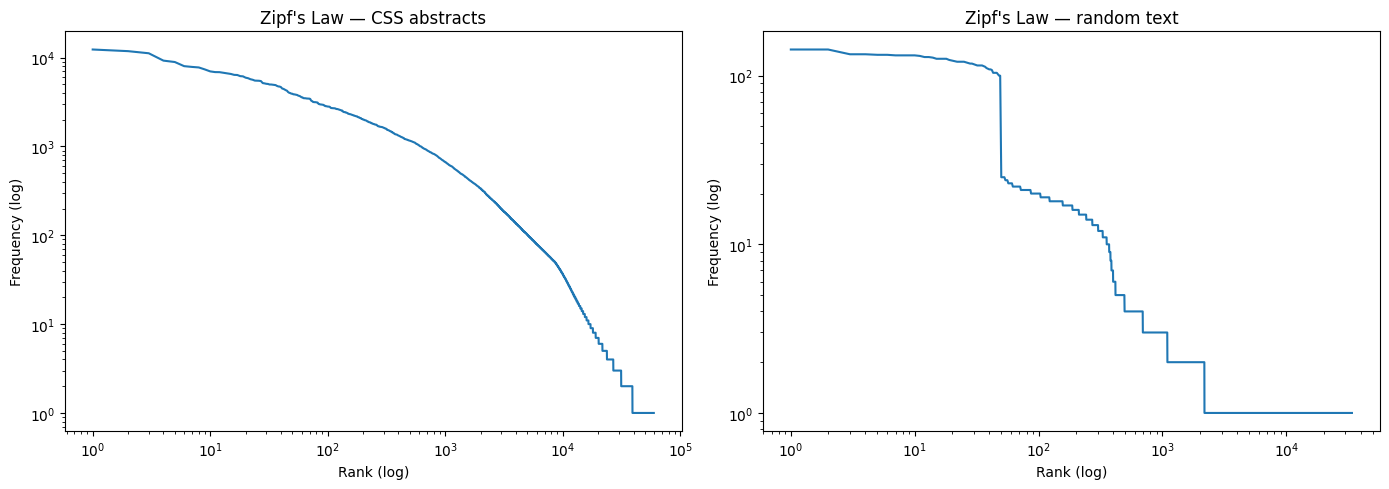

In [15]:
import random

# generate random text
random_text = ''.join(random.choice("abcdefg ") for _ in range(500000))
random_tokens = [t for t in random_text.split() if len(t) >= 2]

random_freq = Counter(random_tokens)
random_counts = sorted(random_freq.values(), reverse=True)
random_ranks = range(1, len(random_counts) + 1)

# real data
real_freq = Counter(abstracts["tokens"].explode().tolist())
real_counts = sorted(real_freq.values(), reverse=True)
real_ranks = range(1, len(real_counts) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].loglog(real_ranks, real_counts)
axes[0].set_xlabel("Rank (log)")
axes[0].set_ylabel("Frequency (log)")
axes[0].set_title("Zipf's Law — CSS abstracts")

axes[1].loglog(random_ranks, random_counts)
axes[1].set_xlabel("Rank (log)")
axes[1].set_ylabel("Frequency (log)")
axes[1].set_title("Zipf's Law — random text")

plt.tight_layout()
plt.show()

**zipf comparison:** the CSS abstracts show a smooth, approximately linear 
relationship on the log-log plot, consistent with zipf's law. the random text 
does not — it has a stepped, flat-then-sharp-drop pattern. this is because 
random letter combinations produce many "words" at similar frequencies (flat 
plateau) and then a long tail of rare unique strings. zipf's law is a property 
of real human language, not random character sequences — it emerges from how 
humans naturally reuse common words while also introducing rarer specialized 
vocabulary.